In [30]:
import torch
from torch import nn
from d2l import torch as d2l

# Encoder
# Source tokens [B, T_src]
#         │
#         ▼
# All Encoder hidden states [B, T_src, H]
#         │
#         ├──────────── Keys
#         └──────────── Values
#
# Decoder time step t'
# Previous hidden state [B, H]
#         │ (unsqueeze)
#         ▼
# Query [B, 1, H]
#         │
#         ▼
# Additive Attention
#         │
#         ├── Attention Weights [B, 1, T_src]
#         └── Context           [B, 1, H]
#                                    │
#  Target Embedding [B, 1, E] ───────┤
#                                    ▼
#                            Concatenate
#                            [B, 1, H + E]
#                                    │
#                                    ▼
#                                   GRU
#                                    │
#                     ┌──────────────┴──────────────┐
#                     ▼                             ▼
#               Output [1, B, H]       New hidden state [L, B, H]
#                     │
#                     ▼
#               Linear [H → V]
#                     │
#                     ▼
#               Logits [B, 1, V]

In [31]:
# AttentionDecoder Interface

class AttentionDecoder(d2l.Decoder):
    
    def __init__(
        self,
    ) -> None:
        super().__init__()
        
    @property
    def attention_weights(
        self,
    ) -> list[torch.Tensor]:
        raise NotImplementedError

In [32]:
# Single Attention Decoder step

batch_size = 2
source_steps = 4

num_hiddens = 6
embed_size = 3
num_layers = 2

# 모든 Encoder Time Step의 Hidden State
# [B, T, H] = [2, 4, 6]
encoder_outputs = torch.randn(
    batch_size,
    source_steps,
    num_hiddens,
)

# Decoder의 이전 Hidden State
# [L, B, H] = [2, 2, 6]
hidden_state = torch.randn(
    num_layers,
    batch_size,
    num_hiddens,
)

# 현재 Decoder Input Token의 Embedding
# [B, E] = [2, 3]
embedding = torch.randn(
    batch_size,
    embed_size,
)

valid_lens = torch.tensor([
    4,
    2,
])

attention = d2l.AdditiveAttention(
    num_hiddens=8,
    dropout=0.0,
)

attention.eval()

# Previous Hidden state의 마지막 layer를 Query로 사용한다.
# [L, B, H] -> [B, H] -> [B, 1, H]
# [2, 2, 6] -> [2, 6] -> [2, 1, 6]
query = (
    hidden_state[-1]
    .unsqueeze(1)
)

with torch.no_grad():
    
    # Context: [B, 1, H]
    context = attention(
        query,           # Query : [B, 1, H] = [2, 1, 6]
        encoder_outputs, # Keys  : [B, T, H] = [2, 4, 6]
        encoder_outputs, # Values: [B, T, H] = [2, 4, 6]
        valid_lens,
    )
    
# Embedding:
# [B, E] -> [B, 1, E]
# [2, 3] -> [2, 1, 3]
embedding = (
    embedding.unsqueeze(1)
)

# concatenate: [B, 1, H+E] = [2, 1, 6+3]
decoder_input = torch.cat(
    (
        context,   # [B, 1, H] = [2, 1, 6]
        embedding, # [B, 1, E] = [2, 1, 3]
    ),
    dim=-1,
)

print(
    "Query shape:",
    tuple(query.shape),
)
print(
    "Keys and Values shape:",
    tuple(encoder_outputs.shape),
)
print(
    "Context shape:",
    tuple(context.shape),
)
print(
    "Embedding shape:",
    tuple(embedding.shape),
)
print(
    "Decoder Input shape:",
    tuple(decoder_input.shape),
)

# [B, 1, H + E]
d2l.check_shape(
    decoder_input,
    (
        batch_size,
        1,
        (
            num_hiddens
            + embed_size
        ),
    ),
)

Query shape: (2, 1, 6)
Keys and Values shape: (2, 4, 6)
Context shape: (2, 1, 6)
Embedding shape: (2, 1, 3)
Decoder Input shape: (2, 1, 9)


In [ ]:
# Seq2SeqAttentionDecoder

class Seq2SeqAttentionDecoder(
    AttentionDecoder
): 
    
    def __init__(
        self,
        vocab_size: int,
        embed_size: int,
        num_hiddens: int,
        num_layers: int,
        dropout: float = 0.0,
    ) -> None:
        super().__init__()
        
        # 이전 Decoder hidden state와 
        # 모든 Encoder hidden state 사이의 Attention weights 계산
        self.attention = d2l.AdditiveAttention(
            num_hiddens=num_hiddens,
            dropout=dropout,
        )
        
        # [B, T_tgt] -> [B, T_tgt, E]
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, 
            embedding_dim=embed_size,
        )
        
        # 각 Decoder time step의 GRU input: [E + H]
        self.rnn = nn.GRU(
            input_size=(
                embed_size
                + num_hiddens
            ),
            hidden_size=num_hiddens,
            num_layers=num_layers,
            dropout=dropout,
        )

        # [H] -> [V]        
        self.dense = nn.LazyLinear(
            out_features=vocab_size,
        )
        
        # 각 Decoder time step에서 계산된 Attention weight를 저장
        self._attention_weights: list[
            torch.Tensor
        ] = []
        
        self.apply(
            d2l.init_seq2seq
        )
        
        
    def init_state(
        self,
        enc_outputs: tuple[
            torch.Tensor,
            torch.Tensor,
        ],
        enc_valid_lens: torch.Tensor | None,
        *args: object,
    ) -> tuple[
        torch.Tensor,
        torch.Tensor,
        torch.Tensor | None,
    ]:
        
        # outputs      : [T_src, B, H]
        # hidden_state : [L, B, H] 
        outputs, hidden_state = enc_outputs
        
        # [T_src, B, H] -> [B, T_src, H]
        encoder_outputs = outputs.permute(
            1,
            0,
            2,
        )
        
        return (
            encoder_outputs, # : [B, T_src, H]
            hidden_state,    # : [L, B, H]
            enc_valid_lens,  # Source valid lengths
        )
        
        
        
    def forward(
        self,
        X: torch.Tensor,
        state: tuple[
            torch.Tensor,
            torch.Tensor,
            torch.Tensor | None,
        ],
    ) -> tuple[
        torch.Tensor,
        tuple[
            torch.Tensor,
            torch.Tensor,
            torch.Tensor | None,
        ],
    ]:
        
        encoder_outputs = state[0]
        hidden_state = state[1]
        encoder_valid_lens = state[2]

    
        # Target token index를 Embedding으로 변환
        # [B, T_tgt] -> [B, T_tgt, E] -> [T_tgt, B, E]  
        embeddings = self.embedding(
            X
        ).permute(
            1,
            0,
            2,
        )
        
        step_outputs: list[
            torch.Tensor
        ] = []
        
        self._attention_weights = []
        
        
        # Target sequence를 time step별로 처리: in [T_tgt, B, E]  
        for embedding in embeddings:
            
            # 이전 Decoder hidden state의 마지막 layer를 
            # 현재 time step의 Query로 사용.
            #
            # [L, B, H] -> [B, H] -> [B, 1, H]
            query = hidden_state[-1].unsqueeze(
                dim=1,
            )
            
            # Context: [B, 1, H]
            context = self.attention(
                query,           # Q:[B, 1, H]
                encoder_outputs, # K:[B, T_src, H]
                encoder_outputs, # V:[B, T_src, H]
                encoder_valid_lens,
            )
            
            # current target embedding: [B, 1, E]
            embedding = embedding.unsqueeze(
                dim=1,
            )
            
            # [B, 1, H + E]
            rnn_input = torch.cat(
                (
                    context,
                    embedding,
                ),
                dim=-1,
            )
            
            
            # [1, B, H], [L, B, H]
            output, hidden_state = self.rnn(
                
                # [B, 1, H+E] -> [1, B, H+E] 
                rnn_input.permute(
                    1,
                    0,
                    2,
                ),
                hidden_state,
            )
            
            # T_tgt x [1, B, H]
            step_outputs.append(
                output
            )
            
            # Attention weights: [B, 1, T_src]
            self._attention_weights.append(
                self.attention.attention_weights
            )
            
        # [T_tgt, B, H]
        outputs = torch.cat(
            step_outputs,
            dim=0,
        )
            
        # [T_tgt, B, H] -> [T_tgt, B, V] -> [B, T_tgt, V]
        logits = self.dense(
            outputs
        ).permute(
            1,
            0,
            2,
        )
            
        return logits, (
            encoder_outputs,
            hidden_state,
            encoder_valid_lens,
        )
        
    @property
    def attention_weights(
        self,
    ) -> list[torch.Tensor]:
        return self._attention_weights

In [34]:
# Encoder와 Attention Decoder 연결

vocab_size = 10
embed_size = 8
num_hiddens = 16
num_layers = 2

batch_size = 4
num_steps = 7


encoder = d2l.Seq2SeqEncoder(
    vocab_size=vocab_size,
    embed_size=embed_size,
    num_hiddens=num_hiddens,
    num_layers=num_layers,
)

decoder = Seq2SeqAttentionDecoder(
    vocab_size=vocab_size,
    embed_size=embed_size,
    num_hiddens=num_hiddens,
    num_layers=num_layers,
)


# [B, T] = [4, 7]
X = torch.zeros(
    (
        batch_size,
        num_steps,
    ),
    dtype=torch.long,
)


valid_lens = torch.tensor([
    7,
    5,
    3,
    1,
])


# [Encoder]
# outputs      : [T_src, B, H]
# hidden_state : [L, B, H]
encoder_result = encoder(
    X
)


# Decoder가 사용할 state:
#
# encoder_outputs : [B, T_src, H]
# hidden_state    : [L, B, H]
# valid_lens      : [B]
decoder_state = decoder.init_state(
    encoder_result,
    valid_lens,
)


# Attention Decoder:
#
# logits:
# [B, T_tgt, V]
#
# final_state:
# (
#     encoder_outputs,
#     hidden_state,
#     valid_lens,
# )
logits, final_state = decoder(
    X,
    decoder_state,
)


print(
    "Input:",
    tuple(X.shape),
)

print(
    "Encoder outputs:",
    tuple(
        encoder_result[0].shape
    ),
)

print(
    "Decoder logits:",
    tuple(logits.shape),
)

print(
    "Stored encoder outputs:",
    tuple(final_state[0].shape),
)

print(
    "Final hidden state:",
    tuple(final_state[1].shape),
)


d2l.check_shape(
    logits,
    (
        batch_size,
        num_steps,
        vocab_size,
    ),
)

d2l.check_shape(
    final_state[0],
    (
        batch_size,
        num_steps,
        num_hiddens,
    ),
)

d2l.check_shape(
    final_state[1],
    (
        num_layers,
        batch_size,
        num_hiddens,
    ),
)

Input: (4, 7)
Encoder outputs: (7, 4, 16)
Decoder logits: (4, 7, 10)
Stored encoder outputs: (4, 7, 16)
Final hidden state: (2, 4, 16)


In [35]:
# 모든 Attention Weight 결합 및 Mask 검증

# Decoder time step마다 저장된 
# Attention weights shape: [B, 1, T_src]
#
# T_tgt개를 dim=1 방향으로 결합:
# T_tgt × [B, 1, T_src] -> [B, T_tgt, T_src]
attention_weights = torch.cat(
    decoder.attention_weights,
    dim=1,
)


print(
    "Attention weights:",
    tuple(attention_weights.shape),
)


# 각 Decoder time step의 Attention Weight 합은 1
print(
    "\nWeight sums:",
)

print(
    attention_weights.sum(
        dim=-1
    )
)


# 네 번째 example의 valid length는 1이다.
#
# 따라서 첫 번째 Encoder time step만 사용할 수 있고,
# 나머지 padding 위치의 Attention Weight는 모두 0이어야 한다.
print(
    "\nFourth example attention weights:",
)

print(
    attention_weights[3]
)


d2l.check_shape(
    attention_weights,
    (
        batch_size,
        num_steps,
        num_steps,
    ),
)

Attention weights: (4, 7, 7)

Weight sums:
tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],
       grad_fn=<SumBackward1>)

Fourth example attention weights:
tensor([[1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.]], grad_fn=<SelectBackward0>)


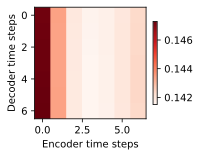

In [36]:
# Attention Weight 시각화

# 첫 번째 example:
#
# Row    : Decoder time step
# Column : Encoder time step
#
# 아직 training하지 않은 Decoder이므로
# 의미 있는 번역 pattern은 나타나지 않는다.
#
# 이 시각화에서는 각 Decoder time step마다
# Encoder 위치별 Attention Weight가 존재한다는
# 구조 자체를 확인한다.

first_example_weights = (
    attention_weights[0]
    .detach()
    .reshape(
        1,
        1,
        num_steps,
        num_steps,
    )
)


d2l.show_heatmaps(
    first_example_weights,
    xlabel="Encoder time steps",
    ylabel="Decoder time steps",
)